<a href="https://colab.research.google.com/github/SergeiVKalinin/spm-reconstruction/blob/main/03_comparing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Comparing Models

Run all 12 models on one image and compare their performance.

Models are defined by four axes: **(S, C, G, P)**
- **S** — State: `S2` (2D) or `S6` (6D geometric)
- **C** — Classifier: `C0` (none) or `CT` (threshold)
- **G** — GP coupling: `G0` (none) or `GC` (conditional)
- **P** — Pass mode: `P1` (single) or `P2` (dual)


In [1]:
!git clone https://github.com/SergeiVKalinin/spm-reconstruction.git 2>/dev/null ||  (cd /content/spm-reconstruction && git pull)
import sys
sys.path.insert(0, '/content/spm-reconstruction')
import importlib, spm_reconstruct
importlib.reload(spm_reconstruct)
print("Ready")

Ready


## 1. What models are available?

In [2]:
from spm_reconstruct import get_model, MODEL_REGISTRY

print(f"{len(MODEL_REGISTRY)} models registered:\n")
for mid, cls in MODEL_REGISTRY.items():
    axes = cls.AXES
    dual = '(dual-pass)' if cls.REQUIRES_DUAL_PASS else ''
    print(f"  {mid:<26}  S={axes['S']}  C={axes['C']}  "
          f"G={axes['G']}  P={axes['P']}  {dual}")

12 models registered:

  (S2, C0, G0, P1)            S=S2  C=C0  G=G0  P=P1  
  (S2, C0, G0, P2)            S=S2  C=C0  G=G0  P=P2  (dual-pass)
  (S2, CT, G0, P1)            S=S2  C=CT  G=G0  P=P1  
  (S2, CT, G0, P2)            S=S2  C=CT  G=G0  P=P2  (dual-pass)
  (S2, CT, GC, P1)            S=S2  C=CT  G=GC  P=P1  
  (S2, CT, GC, P2)            S=S2  C=CT  G=GC  P=P2  (dual-pass)
  (S6, C0, G0, P1)            S=S6  C=C0  G=G0  P=P1  
  (S6, C0, G0, P2)            S=S6  C=C0  G=G0  P=P2  (dual-pass)
  (S6, CT, G0, P1)            S=S6  C=CT  G=G0  P=P1  
  (S6, CT, G0, P2)            S=S6  C=CT  G=G0  P=P2  (dual-pass)
  (S6, CT, GC, P1)            S=S6  C=CT  G=GC  P=P1  
  (S6, CT, GC, P2)            S=S6  C=CT  G=GC  P=P2  (dual-pass)


## 2. Generate a test image with dual-pass

In [3]:
import numpy as np
from spm_data import make_scan

data = make_scan(seed=42, Ny=64, Nx=64,
                 artifacts=['crash','oscillation','drift'],
                 dual_pass=True)
print(data)
print(f"backward scan available: {data.has_backward()}")

ScanData(Ny=64, Nx=64, dual-pass, labelled, seed=42)
backward scan available: True


## 3. Run all 12 models

In [4]:
from spm_reconstruct import Evaluator
from spm_eval.metrics import rmse

ev      = Evaluator()
results = {}
metrics = {}

for mid, cls in MODEL_REGISTRY.items():
    model         = get_model(mid)
    results[mid]  = model.reconstruct(data)
    metrics[mid]  = ev.evaluate(results[mid], data)
    print(f"  {mid:<26} RMSE={metrics[mid]['rmse']:.4f}  "
          f"({results[mid].runtime_s:.1f}s)")

corrupted_rmse = rmse(data.forward, data.true_surface)
print(f"\n  {'Corrupted baseline':<26} RMSE={corrupted_rmse:.4f}")

  (S2, C0, G0, P1)           RMSE=0.1516  (1.4s)
  (S2, C0, G0, P2)           RMSE=0.1371  (1.2s)
  (S2, CT, G0, P1)           RMSE=0.1359  (1.3s)
  (S2, CT, G0, P2)           RMSE=0.1415  (0.7s)
  (S2, CT, GC, P1)           RMSE=0.1446  (0.5s)
  (S2, CT, GC, P2)           RMSE=0.1415  (0.5s)
  (S6, C0, G0, P1)           RMSE=0.1426  (0.6s)
  (S6, C0, G0, P2)           RMSE=0.1314  (0.6s)
  (S6, CT, G0, P1)           RMSE=0.1382  (0.8s)
  (S6, CT, G0, P2)           RMSE=0.1377  (1.0s)
  (S6, CT, GC, P1)           RMSE=0.1726  (0.7s)
  (S6, CT, GC, P2)           RMSE=0.1377  (0.7s)

  Corrupted baseline         RMSE=0.2019


## 4. Comparison table

Sorted by RMSE (best first). The improvement column shows
how much each model reduces error vs the corrupted input.


In [5]:
import numpy as np

ranked = sorted(metrics.items(), key=lambda x: x[1]['rmse'])

print(f"\n{'Model':<26}  {'RMSE':>8}  {'SSIM':>8}  "
      f"{'Cov95':>8}  {'Improvement':>12}")
print("-" * 72)

for mid, rec in ranked:
    imp = 100*(corrupted_rmse - rec['rmse']) / corrupted_rmse
    print(f"{mid:<26}  {rec['rmse']:>8.4f}  {rec['ssim']:>8.4f}  "
          f"{rec['coverage95']:>8.3f}  {imp:>+11.1f}%")

print(f"\n{'Corrupted':26}  {corrupted_rmse:>8.4f}")


Model                           RMSE      SSIM     Cov95   Improvement
------------------------------------------------------------------------
(S6, C0, G0, P2)              0.1314    0.6690     0.381        +34.9%
(S2, CT, G0, P1)              0.1359    0.7224     0.453        +32.7%
(S2, C0, G0, P2)              0.1371    0.6669     0.428        +32.1%
(S6, CT, G0, P2)              0.1377    0.6116     0.282        +31.8%
(S6, CT, GC, P2)              0.1377    0.6116     0.282        +31.8%
(S6, CT, G0, P1)              0.1382    0.7387     0.519        +31.5%
(S2, CT, GC, P2)              0.1415    0.5780     0.275        +29.9%
(S2, CT, G0, P2)              0.1415    0.5780     0.275        +29.9%
(S6, C0, G0, P1)              0.1426    0.7079     0.560        +29.3%
(S2, CT, GC, P1)              0.1446    0.6869     0.450        +28.4%
(S2, C0, G0, P1)              0.1516    0.6437     0.503        +24.9%
(S6, CT, GC, P1)              0.1726    0.6133     0.490        +14.5%

Co

## 5. Bar chart of RMSE

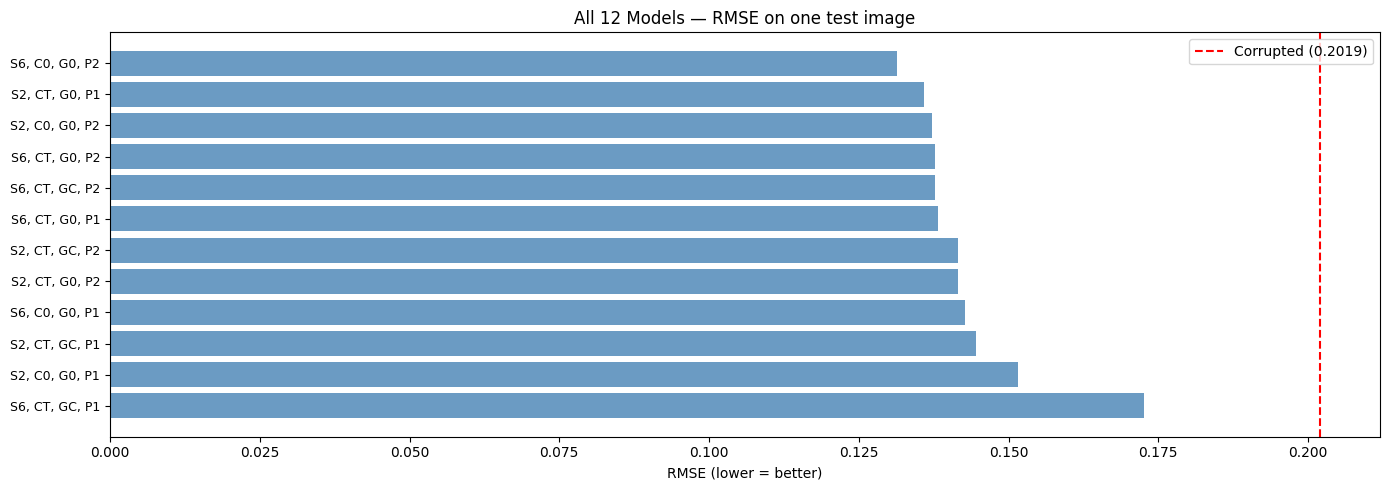

In [6]:
import matplotlib.pyplot as plt

mids   = [mid for mid, _ in ranked]
rmses  = [metrics[mid]['rmse'] for mid in mids]
short  = [m.replace('(','').replace(')','') for m in mids]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(range(len(mids)), rmses, color='steelblue', alpha=0.8)
ax.axvline(corrupted_rmse, color='red', lw=1.5, ls='--',
           label=f'Corrupted ({corrupted_rmse:.4f})')
ax.set_yticks(range(len(mids)))
ax.set_yticklabels(short, fontsize=9)
ax.set_xlabel('RMSE (lower = better)')
ax.set_title('All 12 Models — RMSE on one test image')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. What does each axis contribute?

The key insight: each comparison below changes exactly one component.


In [7]:
# S2 → S6: value of geometric state (same C, G, P)
pairs = [
    ("C0→CT  (classifier)",
     "(S2, C0, G0, P1)", "(S2, CT, G0, P1)"),
    ("G0→GC  (GP coupling)",
     "(S2, CT, G0, P1)", "(S2, CT, GC, P1)"),
    ("S2→S6  (state dim)",
     "(S2, CT, GC, P1)", "(S6, CT, GC, P1)"),
    ("P1→P2  (dual-pass)",
     "(S6, CT, GC, P1)", "(S6, CT, GC, P2)"),
]

print("Controlled comparisons — one axis changes at a time:")
print(f"{'Change':<30}  {'Before':>8}  {'After':>8}  {'Gain':>8}")
print("-" * 60)
for label, m_before, m_after in pairs:
    r_before = metrics[m_before]['rmse']
    r_after  = metrics[m_after]['rmse']
    gain     = 100*(r_before - r_after)/r_before
    print(f"{label:<30}  {r_before:>8.4f}  {r_after:>8.4f}  "
          f"{gain:>+7.1f}%")

Controlled comparisons — one axis changes at a time:
Change                            Before     After      Gain
------------------------------------------------------------
C0→CT  (classifier)               0.1516    0.1359    +10.4%
G0→GC  (GP coupling)              0.1359    0.1446     -6.4%
S2→S6  (state dim)                0.1446    0.1726    -19.3%
P1→P2  (dual-pass)                0.1726    0.1377    +20.2%


## 7. Reconstruction images (subset)

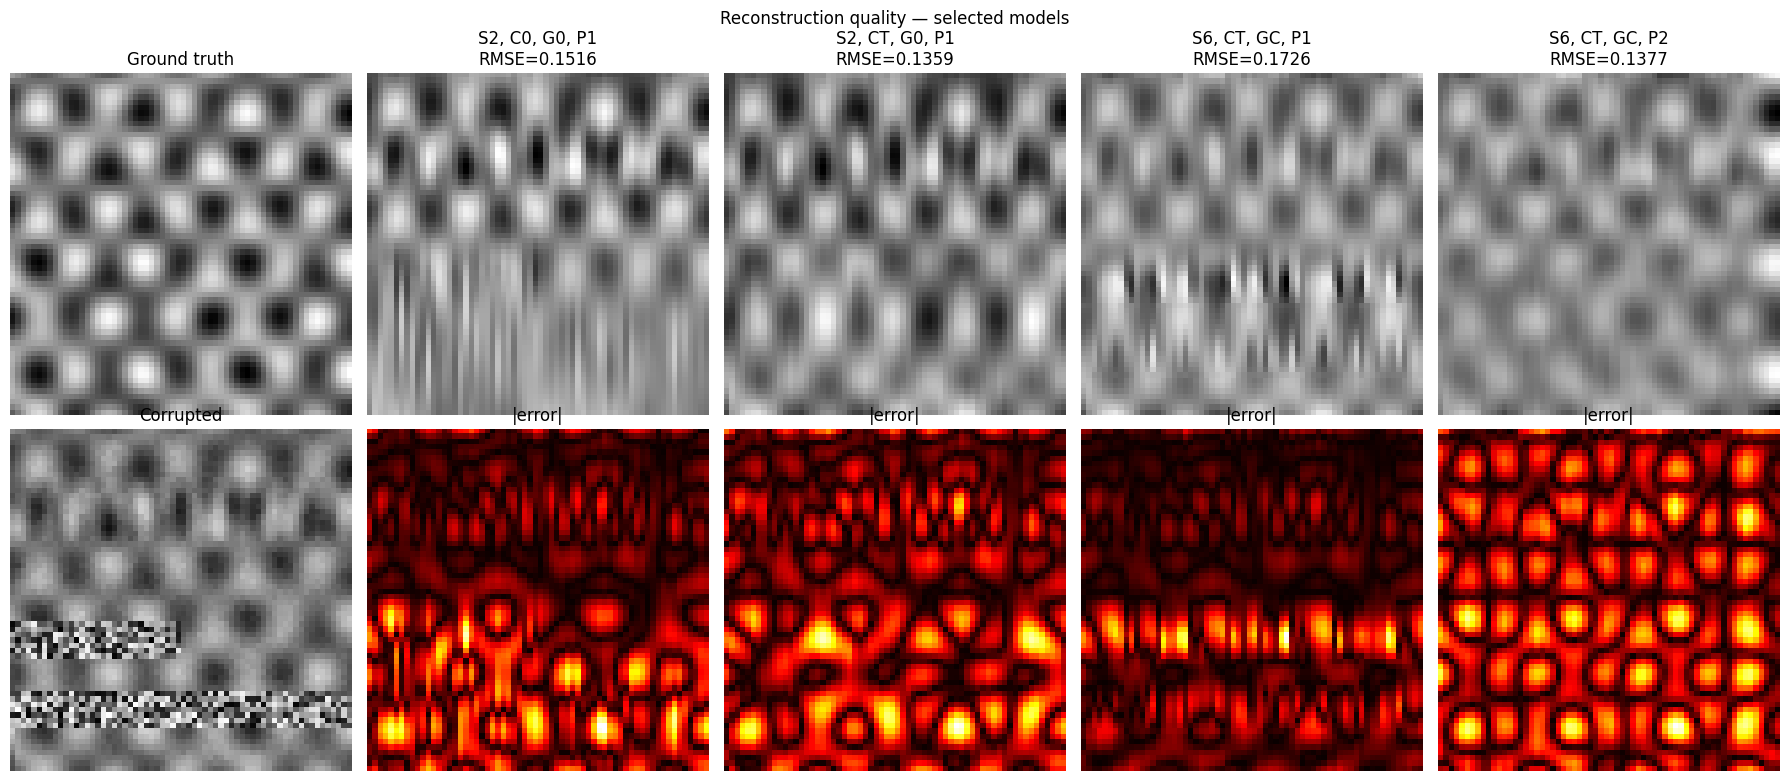

In [8]:
selected = [
    "(S2, C0, G0, P1)",  # simplest
    "(S2, CT, G0, P1)",  # + classifier
    "(S6, CT, GC, P1)",  # + state + GP
    "(S6, CT, GC, P2)",  # + dual-pass
]

fig, axes = plt.subplots(2, len(selected)+1, figsize=(18, 8))

axes[0, 0].imshow(data.true_surface, cmap='gray', origin='upper')
axes[0, 0].set_title('Ground truth'); axes[0, 0].axis('off')
axes[1, 0].imshow(data.forward, cmap='gray', origin='upper')
axes[1, 0].set_title('Corrupted'); axes[1, 0].axis('off')

for i, mid in enumerate(selected):
    r = results[mid]
    rm = metrics[mid]['rmse']
    short = mid.replace('(','').replace(')','')
    axes[0, i+1].imshow(r.reconstructed, cmap='gray', origin='upper')
    axes[0, i+1].set_title(f'{short}\nRMSE={rm:.4f}')
    axes[0, i+1].axis('off')
    err = np.abs(r.reconstructed - data.true_surface)
    axes[1, i+1].imshow(err, cmap='hot', origin='upper')
    axes[1, i+1].set_title('|error|')
    axes[1, i+1].axis('off')

plt.suptitle('Reconstruction quality — selected models')
plt.tight_layout()
plt.show()